# 📈 Intro to Linear Regression

Welcome to your first *real* Machine Learning model! 

**Linear Regression** is the "Hello World" of Machine Learning. The goal is simple: Draw a straight line through your data that best predicts a future outcome.

### The Scenario: Studying vs. Scores
Imagine you are a teacher. You want to predict a student's final test score based purely on **how many hours they studied**. 

Let's import our tools.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-Learn (sklearn) is the standard library for classical ML in Python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. The Data
We don't have a real dataset, so let's generate some mock data. We'll simulate 50 students, their study hours, and their final test scores.

,Hours_Studied,Test_Score
0,4.370861,65.546638
1,9.556429,88.638985
2,7.587945,77.361486
3,6.387926,70.434113
4,2.404168,44.628229


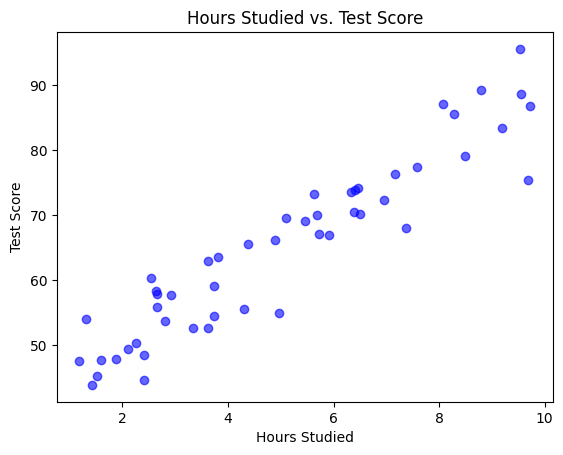

In [18]:
# Set a seed so our random numbers are the same every time
np.random.seed(42)

# Generate 50 random study times between 1 and 10 hours
hours_studied = np.random.uniform(1, 10, 50)

# Generate test scores: Let's say roughly every hour equals 5 points, 
# plus a base score of 40, plus some random noise (because life isn't perfect)
test_scores = 40 + (5 * hours_studied) + np.random.normal(0, 5, 50)

# Put it in a Pandas DataFrame so it's easy to read
df = pd.DataFrame({'Hours_Studied': hours_studied, 'Test_Score': test_scores})

display(df.head())

# Let's visualize the raw data!
plt.scatter(df['Hours_Studied'], df['Test_Score'], color='blue', alpha=0.6)
plt.title('Hours Studied vs. Test Score')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.show()

## 2. The Intuition (Math made easy)

Looking at the scatter plot, you can clearly see an "up-and-to-the-right" trend. 

In algebra, you learned the formula for a line: `y = mx + b`

In Machine Learning, we use the exact same formula, but we call the variables different names:
- `y` is the **Target** (The thing we want to predict: Test Score)
- `x` is the **Feature** (The data we use to make the prediction: Hours Studied)
- `m` is the **Weight** (How much impact does 1 hour of studying have?)
- `b` is the **Bias** (If a student studies 0 hours, what score do they get?)

The Machine Learning model's ONLY job is to figure out the absolute best values for the **Weight** and the **Bias** to draw a line perfectly through the middle of those dots.

## 3. Train / Test Split
We NEVER train our model on 100% of the data. If we did, the model could just memorize the answers, and we wouldn't know if it was actually "learning" the underlying pattern.

Instead, we split the data: 80% to train the model, 20% to test it like an exam.

In [19]:
# Scikit-Learn expects 'X' (Features) to be a 2D array (a DataFrame), 
# and 'y' (Target) to be a 1D array (a Series)
X = df[['Hours_Studied']]  # Note the double brackets to keep it as a DataFrame
y = df['Test_Score']

# Split the data! (test_size=0.2 means 20% is held back for testing, 80% for training)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 40
Testing rows: 10


## 4. Train the Model
This is where the magic happens. Back in the day, you had to write the calculus equations by hand to find the line of best fit. Today, Scikit-Learn does it in 3 lines of code.

In [20]:
# Step 1: Initialize the model
model = LinearRegression()

# Step 2: Fit the model to the TRAINING data (This is the actual "learning" part!)
model.fit(X_train, y_train)

# Step 3: Check what it learned
print(f"The Weight (m) is: {model.coef_[0]:.2f}")
print(f"The Bias (b) is: {model.intercept_:.2f}")

print(f"\nMeaning our formula is:  Test Score = ({model.coef_[0]:.2f} * Hours) + {model.intercept_:.2f}")

The Weight (m) is: 4.85
The Bias (b) is: 40.77

Meaning our formula is:  Test Score = (4.85 * Hours) + 40.77


## 5. Make Predictions and Visualize
Now we can feed our `X_test` data (the 20% we hid from the model) into our trained model, and see what it guesses the test scores should be.

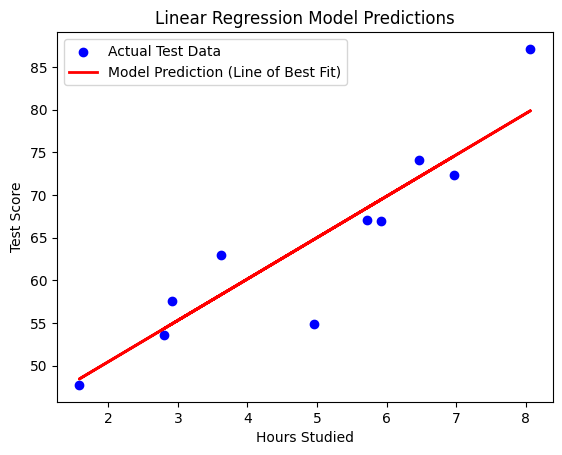

In [21]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Let's visualize the actual test data dots vs the Model's prediction line!
plt.scatter(X_test, y_test, color='blue', label='Actual Test Data')
plt.plot(X_test, predictions, color='red', linewidth=2, label='Model Prediction (Line of Best Fit)')
plt.title('Linear Regression Model Predictions')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.legend()
plt.show()

## 6. Evaluation
How do we know if it's a "good" model? We look at metrics.

**MSE (Mean Squared Error):** The average squared distance between our red line and the actual blue dots. Lower is better. If the line passed exactly through every dot, MSE would be 0.

**R² (R-Squared):** A score roughly between 0 and 1. Think of it as a percentage: "How much of the Final Test Score is currently explained by the Hours Studied?" A score of `1.0` is perfect.

In [22]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-Squared Score: {r2:.2f}")

Mean Squared Error: 19.91
R-Squared Score: 0.84


### Bonus Challenge! 
Use the cell below to predict *your* score if you studied for exactly `7.5` hours. 


In [23]:
# Write your prediction code here!
model.predict([[7.5]])

/home/dev/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([77.12056647])